# 02 — Missing Values

Companion to [`../../data_cleaning/missing_values.md`](../../data_cleaning/missing_values.md).

---

## Why missing data matters

Missing data is the norm, not the exception. Real-world datasets routinely have 5–30% of cells empty. How you handle them affects:

- **Bias**: Deleting rows with missing values can skew your sample.
- **Variance**: Simple imputations (mean/median) shrink variance artificially.
- **Model performance**: Most ML libraries refuse NaN values entirely.

The first step is always to understand the **mechanism** behind the missingness.

## Understanding missingness mechanisms

| Mechanism | Meaning | Safe approach |
|-----------|---------|---------------|
| **MCAR** | Missing Completely At Random — no pattern at all | Deletion is OK but wasteful |
| **MAR** | Missing At Random — depends on observed data | Imputation using other features |
| **MNAR** | Missing Not At Random — depends on the missing value itself | Domain investigation needed |

In this notebook we create a **MAR** scenario: income is more likely to be missing for older users.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

rng = np.random.default_rng(0)
n = 500
df = pd.DataFrame({
    "age":    rng.normal(40, 12, n).round(),
    "income": rng.lognormal(10.5, 0.6, n).round(2),
    "spend":  rng.exponential(100, n).round(2),
})
# Make `income` MAR: missingness depends on age
miss_mask = rng.random(n) < (df['age'] / 200)
df.loc[miss_mask, 'income'] = np.nan
print(f"Missing income: {df['income'].isna().sum()} / {n} ({df['income'].isna().mean()*100:.1f}%)")

Missing income: 110 / 500 (22.0%)


## 1. Detect — where and how much

A quick scan of missingness by column and a heatmap visualization.

In [2]:
print("Missing counts:")
print(df.isna().sum())
print("\nMissing percentages:")
print((df.isna().mean() * 100).round(2))

Missing counts:
age         0
income    110
spend       0
dtype: int64

Missing percentages:
age        0.0
income    22.0
spend      0.0
dtype: float64


### NaN heatmap

Each row is a record. White cells are missing. If you see blocks of white, that's a systematic data collection issue.

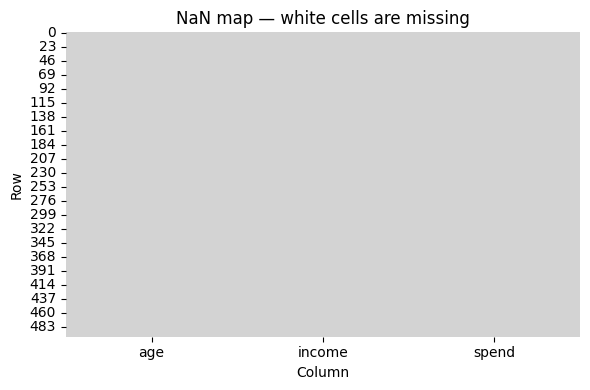

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(df.isna().astype(int), cbar=False, ax=ax, cmap='gray_r', linewidths=0.5, linecolor='lightgray')
ax.set_title('NaN map — white cells are missing'); ax.set_xlabel('Column'); ax.set_ylabel('Row')
plt.tight_layout(); plt.show()

### Is missingness correlated with other variables?

For MAR detection: does the presence of missingness correlate with observed values?

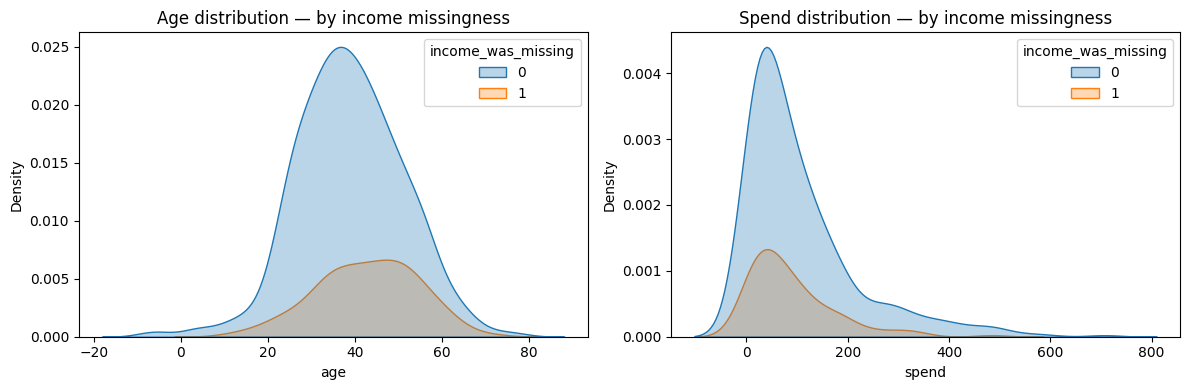

In [4]:
df['income_was_missing'] = df['income'].isna().astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution by missingness
sns.kdeplot(data=df, x='age', hue='income_was_missing', ax=axes[0], fill=True, alpha=0.3)
axes[0].set_title('Age distribution — by income missingness')
axes[0].set_xlabel('age')

# Spend distribution by missingness
sns.kdeplot(data=df, x='spend', hue='income_was_missing', ax=axes[1], fill=True, alpha=0.3)
axes[1].set_title('Spend distribution — by income missingness')
axes[1].set_xlabel('spend')

plt.tight_layout(); plt.show()

### Statistical test: t-test on age by missingness

If the mean age differs significantly between users with and without income, the data is likely MAR.

In [5]:
from scipy import stats
present = df[df['income_was_missing'] == 0]['age']
missing = df[df['income_was_missing'] == 1]['age']
t_stat, p_value = stats.ttest_ind(present, missing)
print(f"Mean age (income present): {present.mean():.1f}")
print(f"Mean age (income missing):  {missing.mean():.1f}")
print(f"t-statistic: {t_stat:.2f}, p-value: {p_value:.4f}")
print(f"\n→ Data is likely **MAR** (p < 0.05: significant difference in age between groups)")

Mean age (income present): 38.8
Mean age (income missing):  42.8
t-statistic: -3.07, p-value: 0.0023

→ Data is likely **MAR** (p < 0.05: significant difference in age between groups)


## 2. Indicator trick

Create a binary flag for each column with missing values. This preserves information — the model can learn that "income was missing" is itself a signal.

In [6]:
df['income_was_missing'] = df['income'].isna().astype(int)
df[['age', 'income', 'spend', 'income_was_missing']].head(10)

,age,income,spend,income_was_missing
0,42.0,78884.17,33.78,0
1,38.0,47676.92,71.94,0
2,48.0,13172.73,42.74,0
3,41.0,23460.72,28.37,0
4,34.0,76067.93,49.88,0
5,44.0,NaN,133.94,1
6,56.0,36101.32,138.24,0
7,51.0,NaN,55.92,1
8,32.0,55973.26,223.74,0
9,25.0,23740.10,75.84,0


### Visualize: does missingness correlate with spend?

Users with missing income might also spend differently.

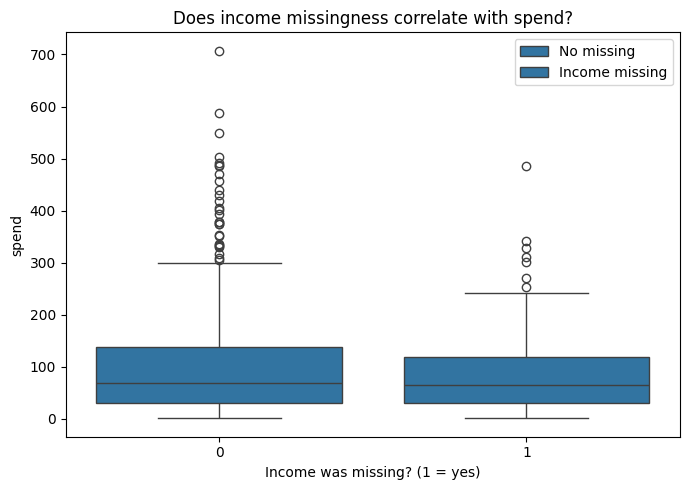

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df, x='income_was_missing', y='spend', ax=ax, label=['No missing', 'Income missing'])
ax.set_xlabel('Income was missing? (1 = yes)')
ax.set_ylabel('spend')
ax.set_title('Does income missingness correlate with spend?')
plt.tight_layout(); plt.show()

## 3. Three imputation strategies

We compare three approaches on the `income` column:

1. **Median imputation** — simple, preserves the center but shrinks variance
2. **KNN imputation** — uses neighboring records to predict missing values
3. **MICE (Multiple Imputation by Chained Equations)** — models each column as a function of others

In [8]:
baseline = SimpleImputer(strategy='median')
knn      = KNNImputer(n_neighbors=5)
mice     = IterativeImputer(random_state=0, max_iter=10)

X = df[['age', 'income', 'spend']]
out = pd.DataFrame({
    'median': baseline.fit_transform(X)[:, 1],
    'knn':    knn.fit_transform(X)[:, 1],
    'mice':   mice.fit_transform(X)[:, 1],
})
out.describe()

,median,knn,mice
count,500.000000,500.000000,500.000000
mean,40078.993800,41508.837348,41520.483147
std,22768.944176,23268.313595,22606.258025
min,7882.950000,7882.950000,7882.950000
25%,27254.115000,26570.917000,27254.115000
50%,34968.230000,36384.460000,41520.271185
75%,44987.385000,49836.449000,44987.385000
max,161478.890000,161478.890000,161478.890000


## 4. Comparing the imputed distributions

Overlay each imputed distribution with the originally observed data. The closer the match, the better the imputation.

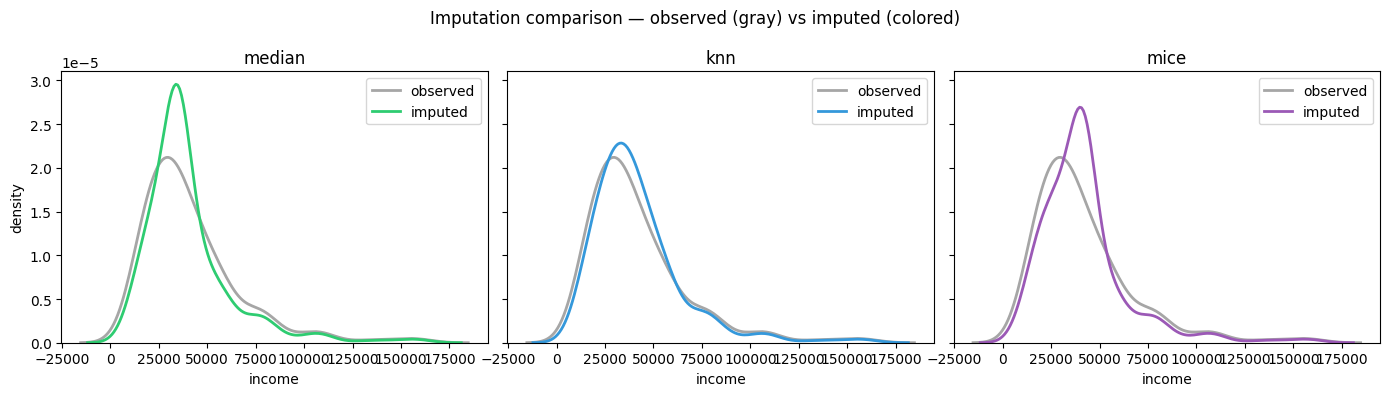

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True, sharey=True)
colors = ['#2ecc71', '#3498db', '#9b59b6']
for ax, (col, color) in zip(axes, zip(['median', 'knn', 'mice'], colors)):
    sns.kdeplot(df['income'].dropna(), ax=ax, label='observed', color='gray', linewidth=2, alpha=0.7)
    sns.kdeplot(out[col], ax=ax, label='imputed', color=color, linewidth=2)
    ax.set_title(col)
    ax.legend()
fig.suptitle('Imputation comparison — observed (gray) vs imputed (colored)', fontsize=12)
axes[0].set_ylabel('density')
plt.tight_layout(); plt.show()

### Variance comparison

Simple imputations like median shrink variance. This table shows the variance before and after each method.

In [10]:
orig_var = df['income'].dropna().var()
med_var = out['median'].var()
knn_var = out['knn'].var()
mice_var = out['mice'].var()
comparison = pd.DataFrame({
    'method': ['original', 'median', 'knn', 'mice'],
    'variance': [orig_var, med_var, knn_var, mice_var],
})
comparison['variance_ratio'] = (comparison['variance'] / orig_var).round(3)
comparison

,method,variance,variance_ratio
0,original,6.555537e+08,1.000
1,median,5.184248e+08,0.791
2,knn,5.414144e+08,0.826
3,mice,5.110429e+08,0.780


### Variance bar chart

Visual comparison of how much each method preserves the original variance.

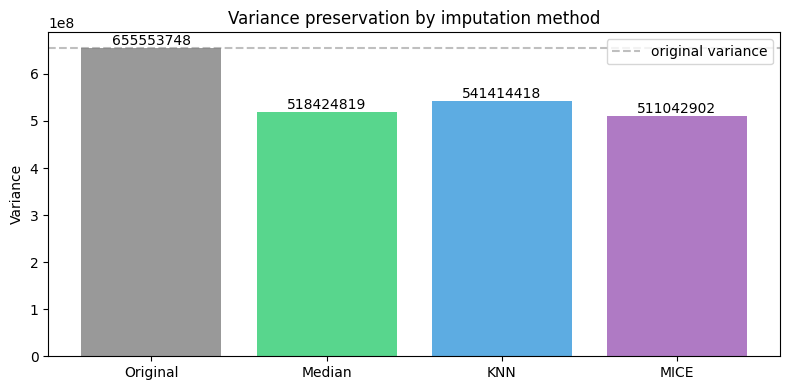

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
methods = ['Original', 'Median', 'KNN', 'MICE']
vars_vals = [df['income'].dropna().var(), out['median'].var(), out['knn'].var(), out['mice'].var()]
bars = ax.bar(methods, vars_vals, color=['gray', '#2ecc71', '#3498db', '#9b59b6'], alpha=0.8)
ax.set_ylabel('Variance'); ax.set_title('Variance preservation by imputation method')
ax.axhline(vars_vals[0], color='gray', linestyle='--', alpha=0.5, label='original variance')
ax.legend()
for bar, v in zip(bars, vars_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100, f'{v:.0f}', ha='center', va='bottom')
plt.tight_layout(); plt.show()

## 5. Impact on downstream model

The real test: does the imputation method affect model performance? We train a simple model to predict `spend` from `age` and `income`.

In [12]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor

X_base = df[['age', 'income']].copy()
y = df['spend']

for method_name, imputer in [('median', SimpleImputer(strategy='median')),
                               ('knn', KNNImputer(n_neighbors=5)),
                               ('mice', IterativeImputer(random_state=0, max_iter=10))]:
    X_imputed = pd.DataFrame(imputer.fit_transform(X_base), columns=X_base.columns, index=X_base.index)
    scores = cross_val_score(RandomForestRegressor(n_estimators=50, random_state=0), X_imputed, y,
                             cv=KFold(5), scoring='r2')
    print(f"{method_name:>6}: R² = {scores.mean():.3f} ± {scores.std():.3f}")

median: R² = -0.331 ± 0.176
   knn: R² = -0.309 ± 0.167
  mice: R² = -0.319 ± 0.162


### Model performance bar chart

Visual comparison of R² scores across imputation methods.

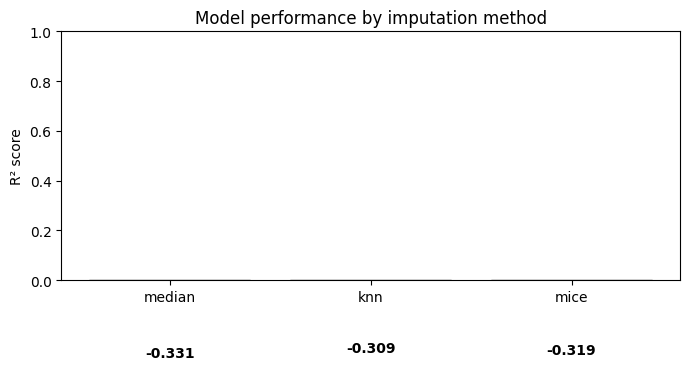

In [13]:
methods = ['median', 'knn', 'mice']
means, stds = [], []
for method_name, imputer in [('median', SimpleImputer(strategy='median')),
                               ('knn', KNNImputer(n_neighbors=5)),
                               ('mice', IterativeImputer(random_state=0, max_iter=10))]:
    X_imputed = pd.DataFrame(imputer.fit_transform(df[['age', 'income']]), columns=['age', 'income'], index=df.index)
    scores = cross_val_score(RandomForestRegressor(n_estimators=50, random_state=0), X_imputed, df['spend'],
                             cv=KFold(5), scoring='r2')
    means.append(scores.mean())
    stds.append(scores.std())

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ecc71', '#3498db', '#9b59b6']
bars = ax.bar(methods, means, yerr=stds, capsize=5, color=colors, alpha=0.8, edgecolor='black')
ax.set_ylabel('R² score'); ax.set_title('Model performance by imputation method')
ax.set_ylim(0, 1)
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{m:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout(); plt.show()

## Takeaways

- **Always check the missingness mechanism** (MCAR vs MAR vs MNAR) before choosing a strategy.
- **Median imputation** is a fine baseline but shrinks variance — check the variance ratio.
- **KNN** respects local structure but is slow on big data (O(n²) in the worst case).
- **MICE / iterative imputation** is the most faithful in the MAR setting — and often gives the best model performance.
- **In all cases, keep the `was_missing` indicator** — it captures information that deletion throws away.
- **Validate**: always compare imputed distributions against observed data and check downstream model impact.